#### Time-Series Modeling for DAB Converters with Recurrent Neural Networks
* Apply Some Good Practices to Improve Accuracy
* Change Recurrent Layers (from Vanilla Recurrent, to LSTM, to BiLSTM)
* Use Power Electronics Insights to Improve Accuracy (Calibration)
* Check "4_Neural_Network/Signal_Domain/rnn_basics.ipynb" for more details

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 Load Time-Series Waveforms of DAB Converters
* Input features: vp and vs
* Output feature: iL

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Load all CSV files from the directory
import glob
file_paths = glob.glob("Waveform/*.csv")

# Initialize empty lists to store data
X1_list = []  # Second column
X2_list = []  # Fourth column
y_list = []   # Third column


def find_zero_crossing(waveform):
    """
    Find the index where the waveform crosses from negative to positive.
    
    Args:
        waveform: numpy array or list containing the waveform data
        
    Returns:
        int: Index of the zero crossing point, or None if no crossing found
    """
    for i in range(1, len(waveform)):
        if waveform[i-1] < 0 and waveform[i] >= 0:
            return i
    return None


apply_calibration = True


# Read each CSV file and extract the required columns
np.random.seed(42)
for file_path in file_paths:
    df = pd.read_csv(file_path)
    # calibrate the data
    if apply_calibration:
        crossing_idx = find_zero_crossing(df.iloc[:, 3])
    else:
        crossing_idx = np.random.randint(0, len(df.iloc[:, 3])-201)

    X1_list.append(df.iloc[crossing_idx:crossing_idx+201, 1])  # Second column
    X2_list.append(df.iloc[crossing_idx:crossing_idx+201, 3])  # Fourth column
    y_list.append(df.iloc[crossing_idx:crossing_idx+201, 2])   # Third column

# Convert lists to numpy arrays
X1 = np.array(X1_list)[..., None]
X2 = np.array(X2_list)[..., None]
y = np.array(y_list)[..., None]

# Combine input features
X = np.concatenate((X1, X2), axis=2)

# First split: 40% train, 60% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.6, random_state=42)

# Second split: Split temp into validation and test (50% each of the remaining 60%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print shapes to verify split
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (40, 201, 2) (40, 201, 1)
Validation set shape: (30, 201, 2) (30, 201, 1)
Test set shape: (30, 201, 2) (30, 201, 1)


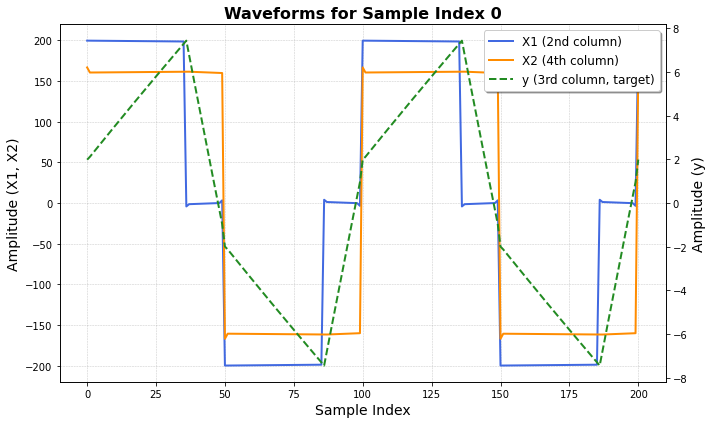

In [3]:
import matplotlib.pyplot as plt

def plot_waveforms(index, X1, X2, y):
    """
    Plot the input waveforms (X1, X2) and target (y) for a given index with professional styling.
    y is plotted on a secondary y-axis.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))
    t = np.arange(X1.shape[1])  # Assuming time axis is the sample index

    # Plot X1 and X2 on the first y-axis
    l1 = ax1.plot(t, X1[index, :, 0], label='X1 (2nd column)', color='royalblue', linewidth=2)
    l2 = ax1.plot(t, X2[index, :, 0], label='X2 (4th column)', color='darkorange', linewidth=2)
    ax1.set_xlabel('Sample Index', fontsize=14)
    ax1.set_ylabel('Amplitude (X1, X2)', fontsize=14)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create a second y-axis for y
    ax2 = ax1.twinx()
    l3 = ax2.plot(t, y[index, :, 0], label='y (3rd column, target)', color='forestgreen', linewidth=2, linestyle='--')
    ax2.set_ylabel('Amplitude (y)', fontsize=14)

    # Combine legends from both axes
    lines = l1 + l2 + l3
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, fontsize=12, frameon=True, shadow=True, loc='upper right')

    plt.title(f'Waveforms for Sample Index {index}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

index = 0
# Example usage: plot the first sample
plot_waveforms(index, X1, X2, y)


#### 2 Implement RNN, LSTM, and BiLSTM for Time-Series Modeling

In [4]:
import torch
import torch.nn as nn

class TimeSeriesRNNModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=16, num_layers=2, output_size=1):
        super(TimeSeriesRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # BiLSTM layers and LayerNorms
        self.lstm_layers = nn.ModuleList()
        self.layernorms = nn.ModuleList()
        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size * 2
            self.lstm_layers.append(nn.LSTM(
                input_size=in_size,
                hidden_size=hidden_size,
                batch_first=True,
                bidirectional=True
            ))
            # LayerNorm over the feature dimension (hidden_size * 2 for bidirectional)
            self.layernorms.append(nn.LayerNorm(hidden_size * 2))

        # Output projection
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        for i, (lstm, ln) in enumerate(zip(self.lstm_layers, self.layernorms)):
            lstm_out, (h_n, c_n) = lstm(x)
            lstm_out = ln(lstm_out)
            # Residual connection if not the first layer and shapes match
            if i > 0 and x.shape == lstm_out.shape:
                x = x + lstm_out
            else:
                x = lstm_out
        return self.fc(x), None


# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Initialize the model
model = TimeSeriesRNNModel(input_size=2, hidden_size=32, num_layers=2, output_size=1)

# Define loss function and optimizer with weight decay (L2 regularization)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler: StepLR with minimal lr of 1e-4
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

# Training parameters
num_epochs = 1000
batch_size = 20
min_lr = 1e-4

# Training loop with best model tracking
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        # Forward pass
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

    # Step the scheduler, but don't let lr go below min_lr
    scheduler.step()
    for param_group in optimizer.param_groups:
        if param_group['lr'] < min_lr:
            param_group['lr'] = min_lr

    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {total_loss/len(X_train_tensor):.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}')

# Load best model
model.load_state_dict(best_model_state)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Epoch [10/1000], Train Loss: 0.3571, Val Loss: 6.2207, LR: 0.001000
Epoch [20/1000], Train Loss: 0.1891, Val Loss: 2.9899, LR: 0.001000
Epoch [30/1000], Train Loss: 0.0927, Val Loss: 1.6157, LR: 0.001000
Epoch [40/1000], Train Loss: 0.0559, Val Loss: 1.0953, LR: 0.001000
Epoch [50/1000], Train Loss: 0.0345, Val Loss: 0.8173, LR: 0.001000
Epoch [60/1000], Train Loss: 0.0248, Val Loss: 0.5789, LR: 0.001000
Epoch [70/1000], Train Loss: 0.0174, Val Loss: 0.4810, LR: 0.001000
Epoch [80/1000], Train Loss: 0.0133, Val Loss: 0.4126, LR: 0.001000
Epoch [90/1000], Train Loss: 0.0114, Val Loss: 0.3522, LR: 0.001000
Epoch [100/1000], Train Loss: 0.0086, Val Loss: 0.3182, LR: 0.000500
Epoch [110/1000], Train Loss: 0.0073, Val Loss: 0.3235, LR: 0.000500
Epoch [120/1000], Train Loss: 0.0067, Val Loss: 0.3216, LR: 0.000500
Epoch [130/1000], Train Loss: 0.0061, Val Loss: 0.3258, LR: 0.000500
Epoch [140/1000], Train Loss: 0.0056, Val Loss: 0.3302, LR: 0.000500
Epoch [150/1000], Train Loss: 0.0051, Val L

In [5]:
# Evaluate the MAE (Mean Absolute Error) on all datasets
mae_criterion = nn.L1Loss()

model.eval()
with torch.no_grad():
    # Training set
    train_outputs, _ = model(X_train_tensor)
    train_mae = mae_criterion(train_outputs, y_train_tensor)
    
    # Validation set
    val_outputs, _ = model(X_val_tensor)
    val_mae = mae_criterion(val_outputs, y_val_tensor)
    
    # Test set
    test_outputs, _ = model(X_test_tensor)
    test_mae = mae_criterion(test_outputs, y_test_tensor)
    
    print(f'Best Validation Loss: {best_val_loss:.4f}')
    print(f'Train MAE: {train_mae:.4f}')
    print(f'Validation MAE: {val_mae:.4f}')
    print(f'Test MAE: {test_mae:.4f}')

Best Validation Loss: 0.2317
Train MAE: 0.1331
Validation MAE: 0.3694
Test MAE: 0.3327


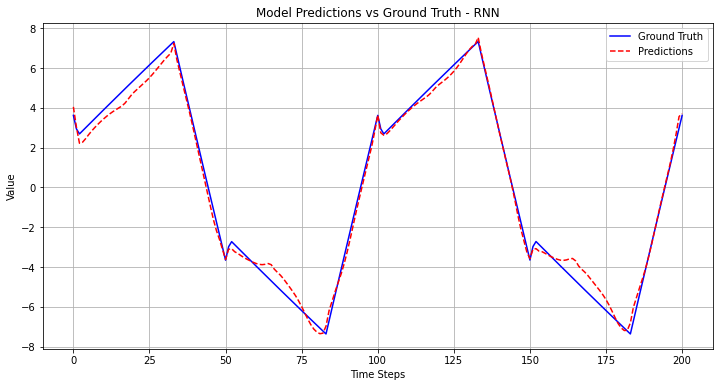

In [6]:
# Import matplotlib.pyplot
import matplotlib.pyplot as plt
import numpy as np

index = 3
# Convert predictions and ground truth to numpy arrays for plotting
predictions = test_outputs.numpy()[index]
ground_truth = y_test_tensor.numpy()[index]

# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot ground truth
plt.plot(ground_truth, label='Ground Truth', color='blue')

# Plot predictions
plt.plot(predictions, label='Predictions', color='red', linestyle='--')

# Add labels and title
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.title('Model Predictions vs Ground Truth - RNN')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()